# DX799 Week 8: K-Nearest Neighbors

This notebook applies K-Nearest Neighbors (KNN) with multiple distance metrics (Euclidean, Manhattan, Minkowski, and Cosine) to the BRFSS 2015 diabetes health indicators dataset. Building on Weeks 1-6, the same five top features are used: GenHlth, BMI, HighBP, Age, and HighChol.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

## Load Data and Split

Same dataset and feature set used throughout Weeks 1-6. KNN requires feature scaling because it relies on distances between points. Features on different scales would cause large-scale features to dominate the distance calculation unfairly.

In [2]:
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

features = ['GenHlth', 'BMI', 'HighBP', 'Age', 'HighChol']
X = df[features]
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (56553, 5)
Test set: (14139, 5)


## Finding Optimal K

KNN makes predictions by looking at the K nearest neighbors of a data point and taking a majority vote. The choice of K is the most important hyperparameter. A small K (like K=1) memorizes the training data and overfits. A large K smooths out the decision boundary but can underfit. Testing a range of K values on the test set identifies where performance peaks.

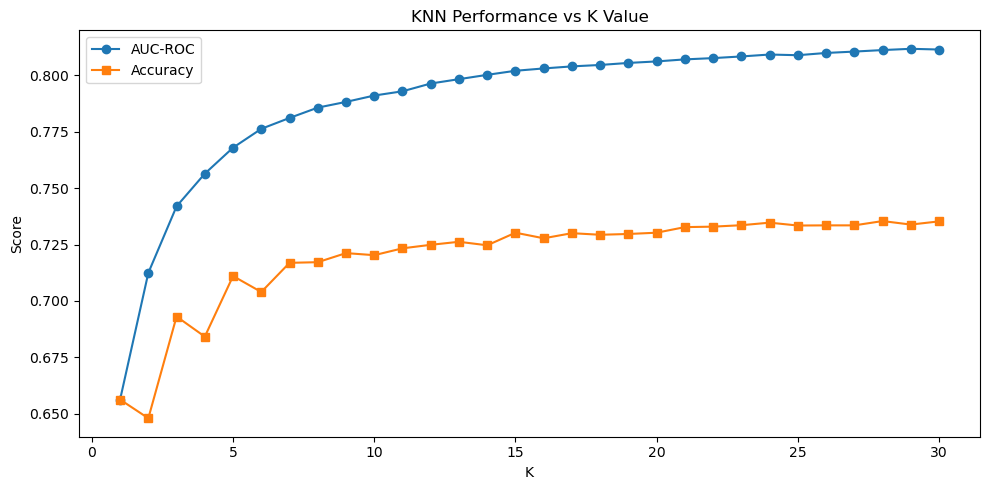

Best K by AUC-ROC: 29
Best AUC-ROC: 0.8118
Accuracy at best K: 0.7339


In [3]:
k_values = range(1, 31)
accuracies = []
auc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_prob))

plt.figure(figsize=(10, 5))
plt.plot(k_values, auc_scores, marker='o', label='AUC-ROC')
plt.plot(k_values, accuracies, marker='s', label='Accuracy')
plt.xlabel('K')
plt.ylabel('Score')
plt.title('KNN Performance vs K Value')
plt.legend()
plt.tight_layout()
plt.savefig('week8_knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = k_values[auc_scores.index(max(auc_scores))]
print(f"Best K by AUC-ROC: {best_k}")
print(f"Best AUC-ROC: {max(auc_scores):.4f}")
print(f"Accuracy at best K: {accuracies[auc_scores.index(max(auc_scores))]:.4f}")

## Extended K Search

The AUC-ROC curve had not flattened by K=30, suggesting the optimal K may be higher. Testing K values up to 100 in steps of 5 to find where performance stabilizes.

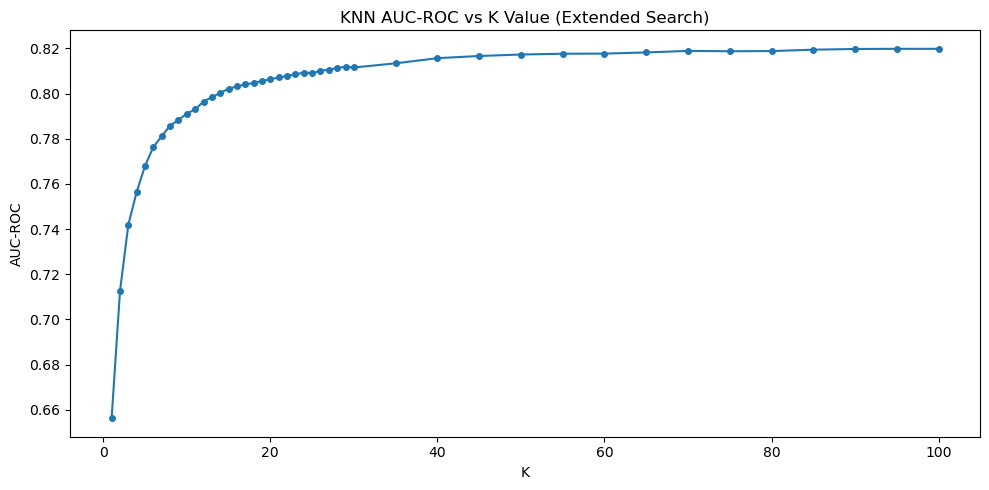

Best K: 100
Best AUC-ROC: 0.8198


In [4]:
k_values_ext = list(range(1, 31)) + list(range(35, 105, 5))
auc_scores_ext = []

for k in k_values_ext:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]
    auc_scores_ext.append(roc_auc_score(y_test, y_prob))

plt.figure(figsize=(10, 5))
plt.plot(k_values_ext, auc_scores_ext, marker='o', markersize=4)
plt.xlabel('K')
plt.ylabel('AUC-ROC')
plt.title('KNN AUC-ROC vs K Value (Extended Search)')
plt.tight_layout()
plt.savefig('week8_knn_k_extended.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_ext = k_values_ext[auc_scores_ext.index(max(auc_scores_ext))]
print(f"Best K: {best_k_ext}")
print(f"Best AUC-ROC: {max(auc_scores_ext):.4f}")

## Distance Metric Comparison

KNN performance depends on how "nearest" is defined. Four distance metrics are compared at K=100 (the optimal K found above): Euclidean, Manhattan, Minkowski (p=3), and Cosine. Each metric measures similarity differently and may produce different results depending on the data structure.

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_distances

metrics = {
    'Euclidean': {'metric': 'minkowski', 'p': 2},
    'Manhattan': {'metric': 'minkowski', 'p': 1},
    'Minkowski (p=3)': {'metric': 'minkowski', 'p': 3},
    'Cosine': {'metric': 'cosine'},
}

metric_results = []

for name, params in metrics.items():
    knn = KNeighborsClassifier(n_neighbors=100, **params)
    knn.fit(X_train_scaled, y_train)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]
    y_pred = knn.predict(X_test_scaled)
    auc = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    metric_results.append({'Metric': name, 'Accuracy': round(acc, 4), 'AUC-ROC': round(auc, 4)})

results_df = pd.DataFrame(metric_results)
print(results_df)

            Metric  Accuracy  AUC-ROC
0        Euclidean    0.7422   0.8198
1        Manhattan    0.7435   0.8197
2  Minkowski (p=3)    0.7440   0.8198
3           Cosine    0.7433   0.8192


## Summary

| Model | K | Distance Metric | Accuracy | AUC-ROC |
|---|---|---|---|---|
| KNN | 100 | Euclidean | 0.7422 | 0.8198 |
| KNN | 100 | Manhattan | 0.7435 | 0.8197 |
| KNN | 100 | Minkowski (p=3) | 0.7440 | 0.8198 |
| KNN | 100 | Cosine | 0.7433 | 0.8192 |

KNN required a surprisingly large K (100) to reach peak performance, with AUC-ROC continuing to improve gradually across the full K=1 to K=100 range without a sharp elbow. This suggests the optimal decision boundary for this dataset is very smooth, and individual neighbors carry little predictive weight on their own. All four distance metrics produced nearly identical results, confirming that the choice of metric is not a meaningful source of variation for this dataset. Best KNN AUC-ROC (0.8198) falls between the linear SVM (0.8149) and the random forest (0.8224), and below logistic regression (0.8232), continuing the pattern across all six prior weeks where simpler linear approaches hold their ground against more complex methods.